# 데이터 살펴보기

예측을 시작하기 전에 어떤 데이터가 있는지, 얼마나 있는지, 어떻게 생겼는지 확인함.

1. 무엇이 들어 있나
2. 예측 시점과 구간
3. 가격
4. 뉴스
5. Reddit
6. 실적과 목표주가
7. 정답 분포
8. 신호가 있는지 확인

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'example' else Path.cwd()))
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (11, 3.5)

from src import Dataset

ds = Dataset()
ds

<Dataset 50종목 기준일 2024-08-13~2026-09-11 522일 (일봉 2023-10-23~2026-09-14)>

## 1. 무엇이 들어 있나

표 다섯 개와 Reddit 이 있음. 모든 표에 `known_at` 이 있는데,
그 값을 **언제 알 수 있게 되었는지**를 뜻함. 데이터를 자르는 기준이 이 열임.

표마다 시작이 다름(일봉·시간봉 2023-10, Reddit 2024-01, 뉴스 2024-08-13). 그래서 기준일은
모든 표가 갖춰진 **2024-08-13 부터**임. 그 앞의 일봉은 지표를 계산할 때 과거로 거슬러 보는 용도임.

In [2]:
for name in ['daily', 'price', 'news', 'earnings', 'analyst']:
    df = ds.table(name, until='2026-01-05')
    print(f'{name:10} {len(df):>9,}행   {list(df.columns)}')

daily         27,593행   ['symbol', 'date_et', 'open', 'high', 'low', 'close', 'volume', 'prev_close', 'ret', 'up', 'known_at']
price        446,857행   ['symbol', 'datetime', 'open', 'high', 'low', 'close', 'volume', 'session', 'known_at']


news       2,235,971행   ['symbols', 'source', 'url', 'title', 'tone', 'positive', 'negative', 'known_at', 'text']
earnings       1,051행   ['symbol', 'known_at', 'eps_estimate', 'eps_reported', 'surprise_pct']
analyst       21,266행   ['symbol', 'known_at', 'firm', 'action', 'target_action', 'target_current', 'target_prior']


In [3]:
ds.table('daily', until='2026-01-05').tail(3)

,symbol,date_et,open,high,low,close,volume,prev_close,ret,up,known_at
27590,LIN,2026-01-02,426.279999,430.809998,422.079987,429.119995,1070472,426.420013,0.006332,1,2026-01-02 16:00:00
27591,GILD,2026-01-02,122.489998,122.593903,121.190002,121.570000,2632083,122.760002,-0.009694,0,2026-01-02 16:00:00
27592,XOM,2026-01-02,120.089996,122.680000,119.606697,122.639999,11863642,120.334999,0.019155,1,2026-01-02 16:00:00


In [4]:
print('subreddit:', ds.subreddits())
print('종목:', len(ds.symbols), '개')
print(', '.join(ds.symbols))

subreddit: ['Daytrading', 'StockMarket', 'Superstonk', 'ValueInvesting', 'investing', 'options', 'stocks', 'wallstreetbets']
종목: 50 개
ADI, AMD, AMGN, AMZN, AVGO, AXP, BA, BKNG, BRK-B, CB, COP, COST, CRM, CSCO, CVS, DE, DELL, DHR, GE, GILD, GLW, GS, IBKR, INTC, JNJ, KO, LIN, LLY, MCD, MS, MSFT, NEM, NFLX, NOW, ORCL, PFE, PLD, PM, QCOM, RTX, TJX, TMO, TMUS, UBER, UNP, V, VZ, WELL, WMT, XOM


## 2. 예측 시점과 구간

`ds.day(기준일)` 은 **기준일 장 마감 시점**에 서서 **다음 거래일**을 예측하는 상황을 만듦.
주말이 끼면 그 사이 뉴스도 전부 쓸 수 있음.

In [5]:
day = ds.day('2026-02-20')      # 금요일
print(f'기준일  {day.date:%Y-%m-%d %a}')
print(f'예측일  {day.target:%Y-%m-%d %a}')
print(f'차단선  {day.cutoff}')

# 휴장일도 건너뛴다
for d in ['2026-07-03', '2026-09-04']:
    x = ds.day(d)
    print(f'{x.date:%m-%d %a} -> {x.target:%m-%d %a}')

기준일  2026-02-20 Fri
예측일  2026-02-23 Mon
차단선  2026-02-23 09:30:00
07-03 Fri -> 07-06 Mon
09-04 Fri -> 09-08 Tue


In [6]:
# days 는 거래일 기준임. 기준일을 포함해서 셈
for n in [1, 5, 20]:
    print(f'days={n:<3} 시작 {day.start_of(days=n):%Y-%m-%d}')

days=1   시작 2026-02-20
days=5   시작 2026-02-13
days=20  시작 2026-01-23


In [7]:
# 차단선 이후 데이터는 나오지 않음
p = day.price(days=1)
print('시간봉 세션별:', p.session.value_counts().to_dict())
print('가장 늦은 known_at:', p.known_at.max(), '| 차단선:', day.cutoff)
print('예측일 일봉이 보이나:', (day.daily(days=5).date_et == day.target).any())

시간봉 세션별: {'pre': 539, 'regular': 350, 'post': 151}
가장 늦은 known_at: 2026-02-23 09:00:00 | 차단선: 2026-02-23 09:30:00
예측일 일봉이 보이나: False


## 3. 가격

일봉과 1시간봉이 있음. 1시간봉에는 정규장 밖 시간외 거래(pre/post)도 들어 있음.

AMD 일봉 726행  2023-10-20 ~ 2026-09-14


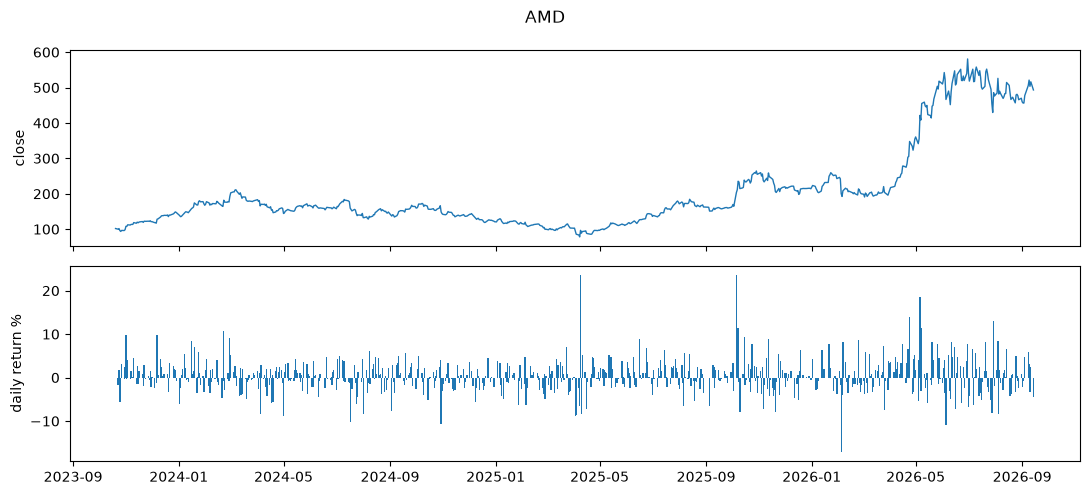

In [8]:
sym = 'AMD'
d = ds.table('daily', symbols=[sym]).sort_values('date_et')
print(f'{sym} 일봉 {len(d):,}행  {d.date_et.min():%Y-%m-%d} ~ {d.date_et.max():%Y-%m-%d}')

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(11, 5))
ax[0].plot(d.date_et, d.close, lw=1)
ax[0].set_ylabel('close')
ax[1].bar(d.date_et, d.ret * 100, width=1.5)
ax[1].set_ylabel('daily return %')
fig.suptitle(sym)
plt.tight_layout(); plt.show()

In [9]:
# 시간외 거래. 실적 발표 같은 건 장 마감 후에 나오므로 여기 먼저 반영됨
h = ds.table('price', symbols=[sym], since='2026-02-18', until='2026-02-21')
h = h.sort_values('datetime')
print(h.session.value_counts().to_dict())
h[['datetime', 'known_at', 'session', 'close', 'volume']].head(8)

{'regular': 21, 'pre': 18, 'post': 9}


,datetime,known_at,session,close,volume
0,2026-02-18 04:00:00,2026-02-18 05:00:00,pre,200.620000,0
1,2026-02-18 05:00:00,2026-02-18 06:00:00,pre,200.580000,0
2,2026-02-18 06:00:00,2026-02-18 07:00:00,pre,199.720000,0
3,2026-02-18 07:00:00,2026-02-18 08:00:00,pre,199.510000,0
4,2026-02-18 08:00:00,2026-02-18 09:00:00,pre,198.370000,0
5,2026-02-18 09:00:00,2026-02-18 09:30:00,pre,198.580000,0
6,2026-02-18 09:30:00,2026-02-18 10:30:00,regular,200.199997,9292394
7,2026-02-18 10:30:00,2026-02-18 11:30:00,regular,202.279999,4005614


In [10]:
# 시간외 봉에는 거래량이 안 들어옴
h.groupby('session')[['volume']].agg(['mean', 'size'])

volume     
                 mean size
session                   
post     0.000000e+00    9
pre      0.000000e+00   18
regular  3.186628e+06   21

## 4. 뉴스

GDELT 가 수집한 기사다. 제목과 논조(tone)가 있고, 일부는 본문까지 크롤링되어 있음.
기사 하나에 종목이 여러 개 붙기도 함.

In [11]:
n = ds.table('news', since='2026-02-01', until='2026-03-01')
print(f'2월 기사 {len(n):,}건')
n[['known_at', 'source', 'symbols', 'title', 'tone']].head(3)

2월 기사 128,701건


,known_at,source,symbols,title,tone
0,2026-02-01,ksl.com,NFLX,Filmmaker behind Netflix's 'most-watched origi...,5.130687
1,2026-02-01,yahoo.com,"MU,AMD,LRCX,AMAT,MS,AXP,STX,VZ,MRVL,WDC,NEM",Stocks Settle Lower on Weakness in Chip Stocks...,0.084104
2,2026-02-01,yahoo.com,WMT,Major change coming to Walmart parking lots ac...,-2.978723


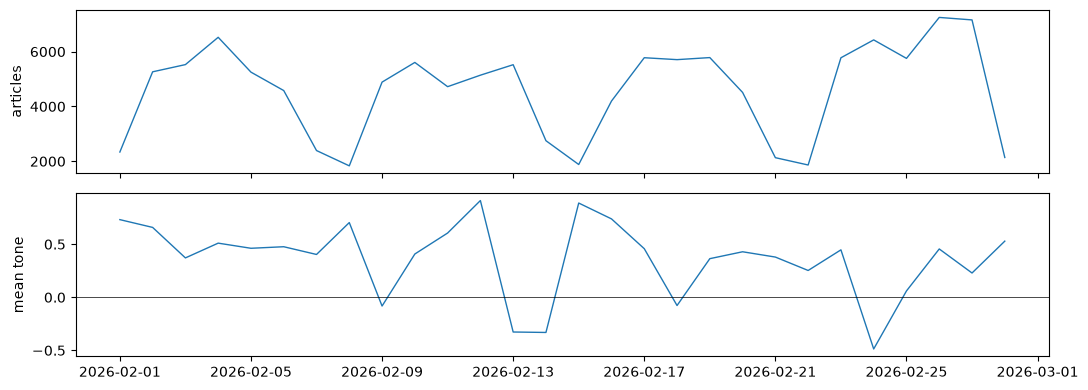

In [12]:
# 날짜별 기사 수와 평균 논조
n['date'] = n.known_at.dt.normalize()
g = n.groupby('date').agg(n_articles=('title', 'size'), tone=('tone', 'mean'))

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(11, 4))
ax[0].plot(g.index, g.n_articles, lw=1); ax[0].set_ylabel('articles')
ax[1].plot(g.index, g.tone, lw=1); ax[1].axhline(0, color='k', lw=.5)
ax[1].set_ylabel('mean tone')
plt.tight_layout(); plt.show()

In [13]:
# 매체별 분포
n.source.value_counts().head(10)

source
iheart.com              16934
yahoo.com                5933
tickerreport.com         3865
themarketsdaily.com      3717
dailypolitical.com       3553
fool.com                 2141
financialcontent.com     2068
indiatimes.com           1628
finanznachrichten.de     1518
insidermonkey.com        1228
Name: count, dtype: int64

### 종목별 기사 수

`symbols` 는 쉼표로 이어진 문자열임. 종목별로 세려면 펼쳐서 한 줄씩 만들어야 함.
기사 하나에 종목이 여러 개 붙기 때문에, 펼친 뒤의 행 수는 원래 기사 수보다 많음.

In [14]:
# 전체 기간 기사를 종목과 붙임
news = ds.table('news', columns=['known_at', 'symbols', 'text'])
news['tags'] = news.symbols.fillna('').str.split(',')

print(f'기사 {len(news):,}건')
print('\n기사 하나에 붙은 종목 수')
print(news.tags.str.len().value_counts().sort_index().head(6).to_string())

기사 3,203,409건

기사 하나에 붙은 종목 수


tags
1    2448108
2     493640
3     168153
4      55339
5      19862
6       8338


In [15]:
# 펼쳐서 (기사 x 종목) 한 줄씩으로 만듦
long = news[['known_at', 'text', 'tags']].explode('tags').rename(columns={'tags': 'symbol'})
long = long[long.symbol.isin(ds.symbols)]      # 우리 50종목만 남김
print(f'{len(long):,}행')

days = len(ds.dates())
by_symbol = long.groupby('symbol').agg(
    articles=('known_at', 'size'),
    with_text=('text', lambda s: s.notna().sum()))
by_symbol['per_day'] = (by_symbol.articles / days).round(1)
by_symbol['text_pct'] = (by_symbol.with_text / by_symbol.articles * 100).round(1)
by_symbol = by_symbol.sort_values('articles', ascending=False)

by_symbol.head(10)

3,573,942행


,articles,with_text,per_day,text_pct
symbol,,,,
NFLX,912813,33627,1259.1,3.7
MSFT,511769,54324,705.9,10.6
WMT,355780,23110,490.7,6.5
GS,277995,30612,383.4,11.0
BA,275326,12050,379.8,4.4
MS,262549,26132,362.1,10.0
INTC,144172,21498,198.9,14.9
ORCL,128391,13273,177.1,10.3
LLY,61198,8208,84.4,13.4


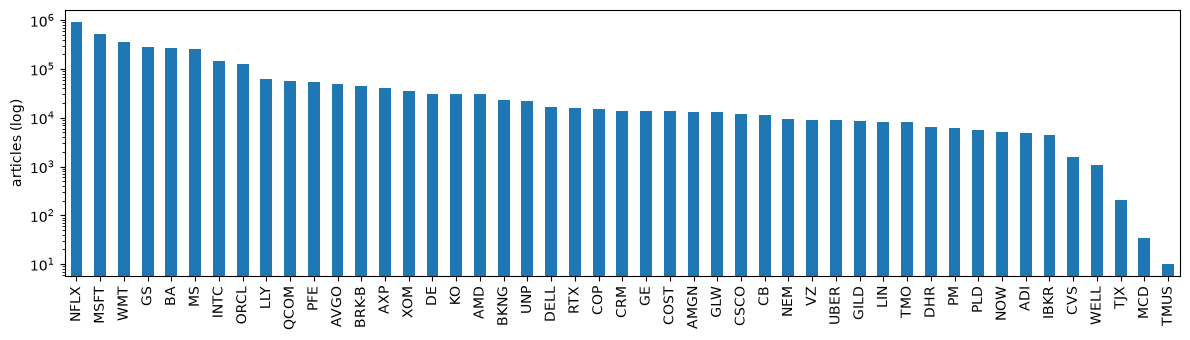

가장 적은 종목
        articles  with_text  per_day  text_pct
symbol                                        
CVS         1575        185      2.2      11.7
WELL        1066        147      1.5      13.8
TJX          209         48      0.3      23.0
MCD           34          0      0.0       0.0
TMUS          10          4      0.0      40.0


In [16]:
by_symbol.articles.plot(kind='bar', logy=True, figsize=(12, 3.5))
plt.ylabel('articles (log)'); plt.xlabel('')
plt.tight_layout(); plt.show()

print('가장 적은 종목')
print(by_symbol.tail(5).to_string())

종목마다 편차가 아주 큼. NFLX 는 90만 건이 넘는데 TMUS 는 열 건뿐임.

GDELT 는 회사 이름으로 기사를 찾기 때문에, 이름이 흔하거나 회사 밖 맥락에서
자주 쓰이는 종목은 관계없는 기사까지 끌어옴. NFLX 가 대표적인데, 넷플릭스는
연예·콘텐츠 기사에 늘 등장함. 반대로 이름이 축약어라 검색에서 빠진 종목도 있음.

**기사 수를 그대로 feature 로 쓰면 종목 간 비교가 안 됨.** 그 종목의 평소
기사량 대비 몇 배인지 같은 형태로 바꿔서 써야 함.

In [17]:
# 평소 대비 얼마나 많은지로 바꾸면 종목끼리 비교가 됨
daily_count = (long.assign(date=long.known_at.dt.normalize())
               .groupby(['symbol', 'date']).size().rename('n').reset_index())

base = daily_count.groupby('symbol').n.median().rename('median')
daily_count = daily_count.join(base, on='symbol')
daily_count['ratio'] = daily_count.n / daily_count['median']

print('기사량이 평소의 몇 배였나 (상위)')
top = daily_count.sort_values('ratio', ascending=False).head(8)
print(top[['symbol', 'date', 'n', 'median', 'ratio']].round(1).to_string(index=False))

기사량이 평소의 몇 배였나 (상위)
symbol       date   n  median  ratio
   CVS 2025-08-21 611     1.0  611.0
   CVS 2024-10-18 203     1.0  203.0
   PLD 2025-07-02 659     5.0  131.8
  COST 2025-01-28 677    12.0   56.4
  COST 2024-12-20 643    12.0   53.6
  COST 2025-09-02 633    12.0   52.8
   COP 2026-01-07 629    12.0   52.4
   COP 2026-01-05 565    12.0   47.1


In [18]:
# 본문이 있는 기사
full = ds.table('news', since='2026-02-20', until='2026-02-21')
has = full[full.text.notna()]
print(f'{len(has):,} / {len(full):,} 건에 본문이 있음')
print(has.iloc[0].title)
print()
print(has.iloc[0].text[:400])

520 / 4,512 건에 본문이 있음
Back Near $1,000, Is Costco Stock a Buy Now?

Shares of membership-based wholesale retailer Costco Wholesale (NASDAQ: COST) are once again trading at levels near $1,000 after rising about 15% this year, crushing the S&P 500. Is the stock's strong outperformance a sign that shares are undervalued, or does its recent rise make the investment decision to buy even more difficult?
Ultimately, the investing question with Costco stock is not whether


## 5. Reddit

종목별로 나뉘어 있지 않다. 시장 전체 분위기를 보는 용도임.
글(posts)과 댓글(comments)이 따로 있음.

Reddit 은 `known_at` 이 없고 **올라온 시각(`created_et`)** 으로 자름. 본문은 올라온 직후 수집되어
cutoff 에 알 수 있는 정보가 맞음. 단 `score` 와 `n_comments` 는 **36시간 뒤** 다시 긁은 값이라
그 시점에는 모르는 미래 정보임. feature 로 쓰지 말 것.

In [19]:
r = ds.reddit('stocks', since='2026-02-20', until='2026-02-24', kind='both')
print(f'{len(r):,}건', r.kind.value_counts().to_dict())
r[['created_et', 'kind', 'author', 'score', 'title']].head(5)

9,500건 {'comments': 9178, 'posts': 322}


,created_et,kind,author,score,title
0,2026-02-20 00:00:40,comments,Echo-Possible,1,NaN
1,2026-02-20 00:01:02,comments,gummi_eater,1,NaN
2,2026-02-20 00:02:27,comments,Echo-Possible,1,NaN
3,2026-02-20 00:02:48,comments,futurefinancebro69,1,NaN
4,2026-02-20 00:02:51,posts,Apprehensive-War4380,1,AI chatbot idea


In [20]:
# subreddit 별 규모
rows = []
for s in ds.subreddits():
    c = ds.reddit(s, since='2026-02-01', until='2026-03-01', kind='comments')
    p = ds.reddit(s, since='2026-02-01', until='2026-03-01', kind='posts')
    rows.append({'subreddit': s, 'posts': len(p), 'comments': len(c)})
pd.DataFrame(rows).sort_values('comments', ascending=False)

,subreddit,posts,comments
7,wallstreetbets,6035,699766
6,stocks,3249,78054
2,Superstonk,2696,71027
3,ValueInvesting,2034,56113
0,Daytrading,5144,46287
4,investing,1988,42674
1,StockMarket,684,24215
5,options,822,10513


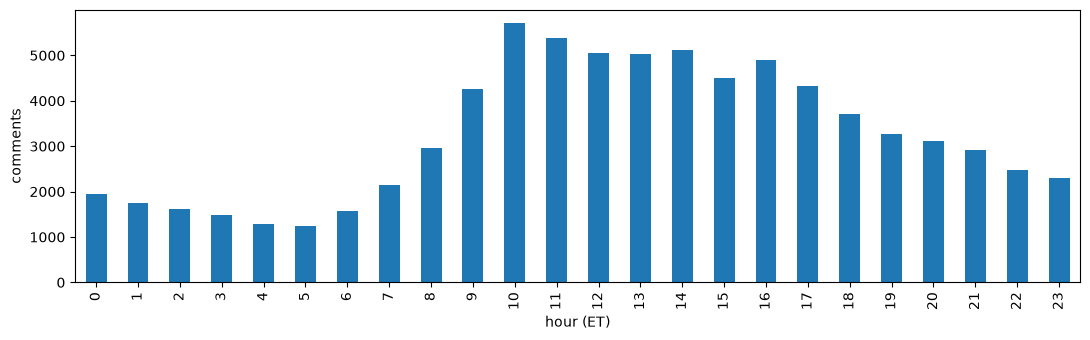

In [21]:
# 하루 중 언제 올라오나 (미 동부 기준)
c = ds.reddit('stocks', since='2026-02-01', until='2026-03-01', kind='comments')
c.created_et.dt.hour.value_counts().sort_index().plot(kind='bar')
plt.xlabel('hour (ET)'); plt.ylabel('comments'); plt.tight_layout(); plt.show()

## 6. 실적과 목표주가

`earnings` 는 실적 발표, `analyst` 는 증권사 목표주가와 투자의견임.
둘 다 발표 시각이 `known_at` 에 들어 있음.

In [22]:
e = ds.table('earnings')
print(f'실적 발표 {len(e):,}건')
e.sort_values('known_at').tail(3)

실적 발표 1,200건


,symbol,known_at,eps_estimate,eps_reported,surprise_pct
1197,DELL,2026-09-01 16:00:00,4.92,7.04,43.14
1198,AVGO,2026-09-02 16:00:00,3.24,3.32,2.53
1199,ORCL,2026-09-10 16:00:00,1.74,1.92,10.45


In [23]:
# 실적은 대부분 장 마감 후나 개장 전에 나옴
e.known_at.dt.strftime('%H:%M').value_counts().head(6)

known_at
16:00    497
06:00    318
07:00    294
08:00     62
05:00      7
17:00      5
Name: count, dtype: int64

In [24]:
a = ds.table('analyst')
print(f'목표주가 변경 {len(a):,}건')
print(a.action.value_counts().head().to_dict())
a.sort_values('known_at').tail(3)

목표주가 변경 23,504건
{'main': 17043, 'up': 1783, 'init': 1608, 'down': 1554, 'reit': 1516}


,symbol,known_at,firm,action,target_action,target_current,target_prior
23501,MCD,2026-09-14 15:09:44,Morgan Stanley,main,Lowers,308.0,319.0
23502,MCD,2026-09-14 17:52:51,Deutsche Bank,main,Lowers,300.0,325.0
23503,ORCL,2026-09-14 20:38:17,Freedom Broker,main,Lowers,205.0,210.0


## 7. 정답 분포

전날 종가 대비 등락률로 다섯 구간을 나눔.

In [25]:
ds.balance()

,이름,비율%
0,급하락,7.4
1,하락,24.1
2,보합,32.9
3,상승,27.4
4,급상승,8.3


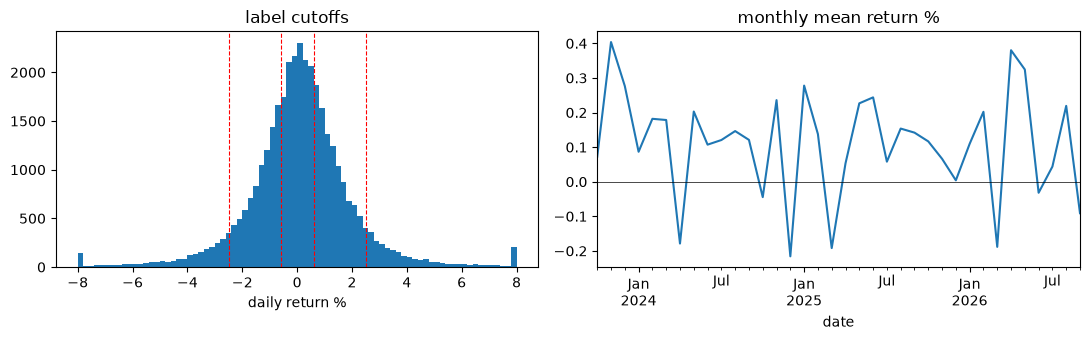

In [26]:
lab = ds.labels()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(lab.ret_pct.clip(-8, 8), bins=80)
for cut in (-2.5, -0.6, 0.6, 2.5):
    ax[0].axvline(cut, color='r', lw=.8, ls='--')
ax[0].set_xlabel('daily return %'); ax[0].set_title('label cutoffs')

lab.groupby(lab.date.dt.to_period('M')).ret_pct.mean().plot(ax=ax[1])
ax[1].axhline(0, color='k', lw=.5); ax[1].set_title('monthly mean return %')
plt.tight_layout(); plt.show()

In [27]:
# 종목마다 성격이 다르다. 변동성이 큰 종목은 급등락 비중이 높음
by_sym = lab.groupby('symbol').agg(
    volatility=('ret_pct', 'std'),
    big_move_share=('label', lambda s: s.isin([0, 4]).mean()))
by_sym.sort_values('volatility', ascending=False).head(8).round(3)

,volatility,big_move_share
symbol,,
INTC,4.079,0.392
DELL,3.955,0.374
AMD,3.719,0.382
ORCL,3.220,0.277
AVGO,3.185,0.321
GLW,3.068,0.23
NOW,2.844,0.243
QCOM,2.725,0.223


## 8. 신호가 있는지 확인

예측 시점에 알 수 있는 값 중 다음날 등락과 관계가 있는 것이 있는지 봄.
개장 전 시간외 거래가 가장 직접적인 후보임.

In [28]:
def pre_move(day):
    """개장 전 시간외 거래에서의 등락률(%)."""
    # hours=20 이면 전날 13:30 이후라 대상일 pre 봉만 잡힘. days=1 은 기준일 pre 까지 섞임
    p = day.price(hours=20, columns=['symbol', 'datetime', 'close', 'session'])
    pre = p[p.session == 'pre'].sort_values('datetime').groupby('symbol')['close']
    return pre.apply(lambda s: s.iloc[-1] / s.iloc[0] - 1 if len(s) > 1 else np.nan) * 100


rows = []
for d in ds.days(since='2026-01-01'):
    v = pre_move(d)
    y = d.y.set_index('symbol')
    for sym, x in v.items():
        if sym in y.index and pd.notna(x):
            rows.append({'pre': x, 'ret': y.loc[sym, 'ret_pct'], 'label': int(y.loc[sym, 'label'])})

sig = pd.DataFrame(rows)
print(f'{len(sig):,}건')
print('순위상관:', round(sig.pre.corr(sig.ret, method='spearman'), 4))

8,618건


순위상관: 0.2316


In [29]:
# 개장 전 움직임을 5분위로 나눠 다음날 등락을 봄
q = pd.qcut(sig.pre, 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
tab = sig.groupby(q, observed=True).agg(
    mean_ret=('ret', 'mean'),
    up_rate=('label', lambda s: (s >= 3).mean()),
    n=('ret', 'size'))
tab.round(3)

,mean_ret,up_rate,n
pre,,,
Q1,-0.686,0.273,1724
Q2,-0.195,0.304,1723
Q3,0.107,0.352,1724
Q4,0.329,0.397,1723
Q5,0.993,0.513,1724


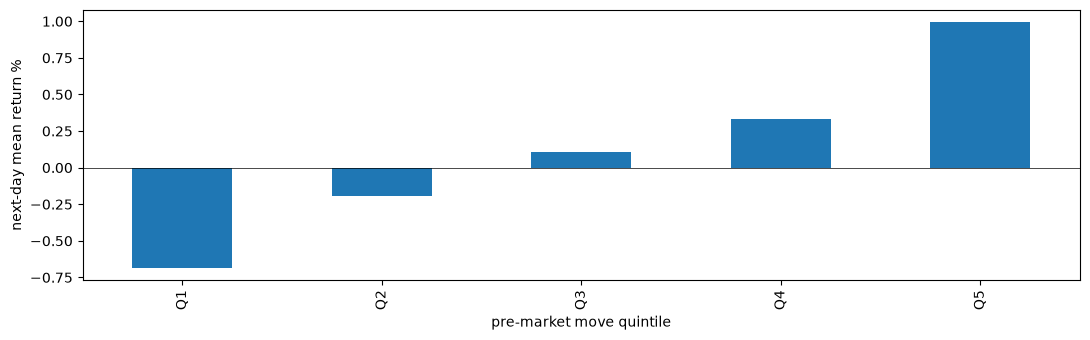

In [30]:
tab.mean_ret.plot(kind='bar')
plt.axhline(0, color='k', lw=.5)
plt.ylabel('next-day mean return %'); plt.xlabel('pre-market move quintile')
plt.tight_layout(); plt.show()

관계가 보인다면 feature 로 쓸 만하다는 뜻임.

다른 것들도 같은 방식으로 확인해 보면 됨.

- 전날 등락률, 최근 5일 등락률
- 기사 수, 평균 tone
- Reddit 댓글 수
- 실적 발표 직후인지
- RSI, MACD, 볼린저 밴드 (`src/features/`)

모델을 만드는 쪽은 `2_modeling.ipynb` 로 이어진다.